## Michelle A. Gómez López - 741902
## Simulación de procesos fiancieros

## 27/08/2026
__________

# Simulacion de Movimiento Browniano y Apuesta Arriesgada

## 1. Simulacion del movimiento browniano

El movimiento browniano es el movimiento aleatorio que se observa en las particulas que se hallan en un medio fluido, como resultado de choques contra las moleculas de dicho fluido.

Para simular el movimiento, en lugar de usar las ecuaciones integro-diferenciales que describen Einstein, se usa una caminata aleatoria para los tres ejes $x$, $y$, $z$ de la siguiente forma:

$$W_i = W_{i-1} + X_i\sqrt{\Delta t}$$

donde $\Delta t$ es un intervalo de tiempo y

$$X_i = \begin{cases} 1 \\ -1 \end{cases}$$

se escoge de forma aleatoria con la misma probabilidad.

Se simulan **10 segundos** con un $\Delta t = 0.001$ y se representa en un grafico 3D.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registra el proyector 3D)

np.random.seed(32)

T = 10           # segundos a simular
dt = 0.001       # intervalo de tiempo
N = int(T / dt)  # numero de pasos

# X_i = +1 o -1 con la misma probabilidad, uno por cada eje (x, y, z) y cada paso
X = np.random.choice([-1, 1], size=(N, 3))

# Incremento de cada paso: X_i * sqrt(dt)
incrementos = X * np.sqrt(dt)

# Caminata aleatoria acumulada: W_i = W_{i-1} + incremento_i, con W_0 = 0
W = np.vstack([np.zeros(3), np.cumsum(incrementos, axis=0)])

x, y, z = W[:, 0], W[:, 1], W[:, 2]

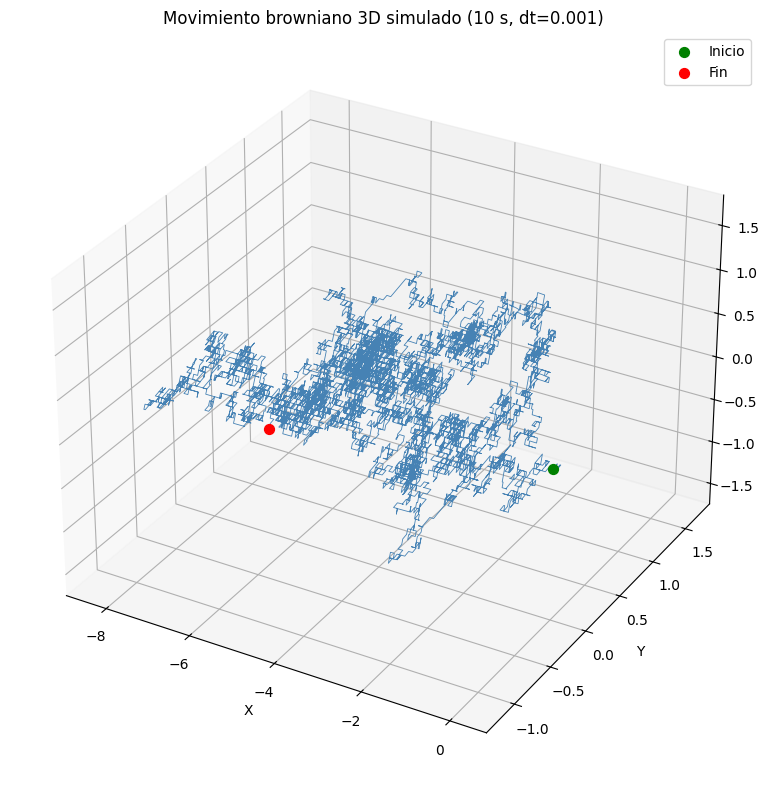

In [2]:
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection="3d")
ax.plot(x, y, z, color="steelblue", linewidth=0.6)
ax.scatter(*W[0], color="green", s=50, label="Inicio")
ax.scatter(*W[-1], color="red", s=50, label="Fin")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title(f"Movimiento browniano 3D simulado ({T} s, dt={dt})")
ax.legend()
plt.tight_layout()
plt.show()

## 2. Apuesta arriesgada

Un jugador, con 20 pesos de capital inicial, decide apostar a un volado (con una moneda perfectamente nivelada) la mitad de su capital si este es mayor o igual a 6 pesos, de lo contrario, solo 2. Esto es, el capital $C_i$ en cada volado $V_i$ se describe como

$$C_{i+1} = C_i + V_i A_i$$

donde la apuesta es

$$A_i = \begin{cases} C_i/2, & \text{si } C_i \geq 6 \\ 2, & \text{de lo contrario} \end{cases}$$

1. Graficar la evolucion del capital hasta quedar en cero.
2. Determinar el numero de volados promedio para quedar en quiebra usando simulacion Montecarlo para 10,000 apostadores.
3. Mostrar un histograma del numero de volados.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(32)

CAPITAL_INICIAL = 20
MAX_VOLADOS = 100_000


def simular_un_jugador(capital_inicial=CAPITAL_INICIAL, max_volados=MAX_VOLADOS):
    trayectoria = [capital_inicial]
    c = capital_inicial
    while c > 0 and len(trayectoria) <= max_volados:
        apuesta = c / 2 if c >= 6 else 2
        v = np.random.choice([-1, 1])
        c = c + v * apuesta
        trayectoria.append(c)
    return np.array(trayectoria)

### 2.1 Evolucion del capital de un jugador hasta la quiebra

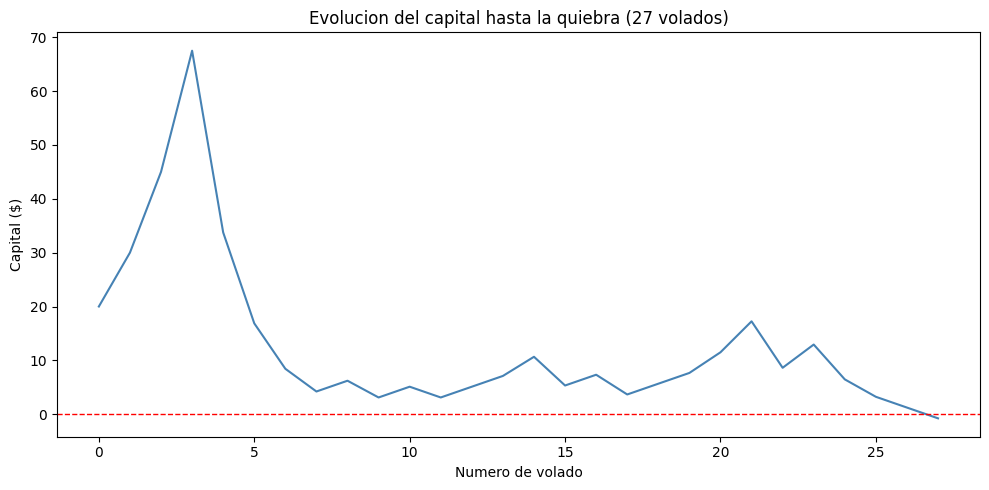

In [4]:
trayectoria = simular_un_jugador()

plt.figure(figsize=(10, 5))
plt.plot(trayectoria, color="steelblue")
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.title(f"Evolucion del capital hasta la quiebra ({len(trayectoria) - 1} volados)")
plt.xlabel("Numero de volado")
plt.ylabel("Capital ($)")
plt.tight_layout()
plt.show()

### 2.2 Numero de volados promedio para quebrar (Monte Carlo, 10,000 apostadores)

Se simulan los 10,000 apostadores de forma vectorizada: se mantiene un arreglo de capitales y una mascara de "activos", y en cada ronda solo se actualiza a quienes siguen jugando.

In [5]:
M = 10_000
capital = np.full(M, float(CAPITAL_INICIAL))
activo = np.ones(M, dtype=bool)
volados = np.zeros(M, dtype=int)

paso = 0
while activo.any() and paso < MAX_VOLADOS:
    idx = np.where(activo)[0]
    v = np.random.choice([-1, 1], size=idx.size)
    apuesta = np.where(capital[idx] >= 6, capital[idx] / 2, 2)
    capital[idx] = capital[idx] + v * apuesta
    volados[idx] += 1
    activo[idx] = capital[idx] > 0
    paso += 1

print(f"Numero promedio de volados para quedar en quiebra: {volados.mean():.2f}")
print(f"Mediana: {np.median(volados):.0f}")
print(f"Minimo: {volados.min()}  Maximo: {volados.max()}")

Numero promedio de volados para quedar en quiebra: 26.30
Mediana: 20
Minimo: 5  Maximo: 192


### 2.3 Histograma del numero de volados

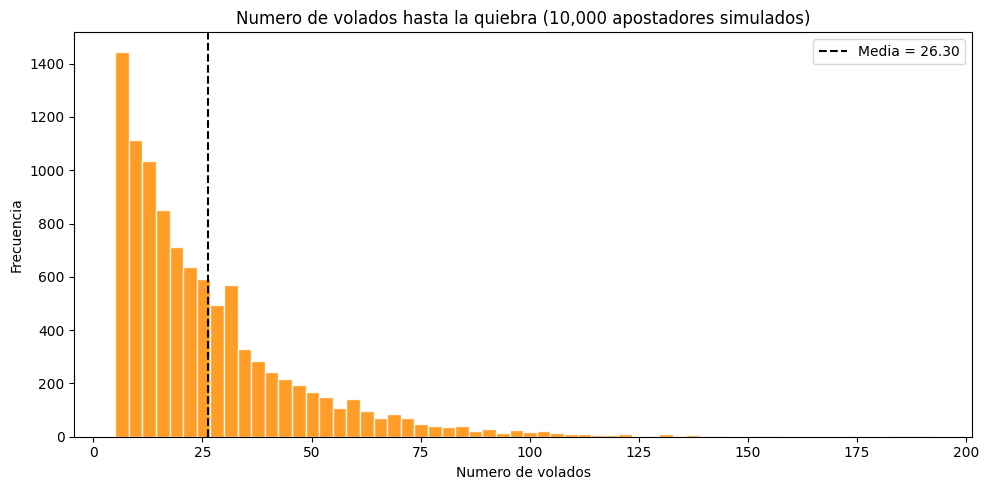

In [6]:
plt.figure(figsize=(10, 5))
plt.hist(volados, bins=60, color="darkorange", edgecolor="white", alpha=0.85)
plt.axvline(volados.mean(), color="black", linestyle="--", label=f"Media = {volados.mean():.2f}")
plt.title(f"Numero de volados hasta la quiebra ({M:,} apostadores simulados)")
plt.xlabel("Numero de volados")
plt.ylabel("Frecuencia")
plt.legend()
plt.tight_layout()
plt.show()